# Grand River Transit (GRT) Data Analysis

Exploring GTFS static schedule data and live trip-update data to analyze service reliability, 
route characteristics, and operational patterns across the GRT network.

> **Data note:** Results and charts below reflect live data collected September 1 – 6, 2026. 
> Re-running the collector script over a different period will produce a different 
> dataset, and therefore different specific numbers, but the same methodology applies.

> **Status:** This project is a work in progress, more questions and analyses are still being added.

> **Jump to Analysis:** Scroll down for the individual analysis questions, each with SQL/Pandas code, charts, and findings.

In [1]:
%load_ext sql
%config SqlMagic.displaylimit = 1000
%sql sqlite:///GRT_GTFS/Trip_Updates_Static_Feed.db

Connecting to 'sqlite:///GRT_GTFS/Trip_Updates_Static_Feed.db'

In [2]:
%%sql

PRAGMA cache_size = -6000000;
PRAGMA journal_mode = WAL;
PRAGMA synchronous = OFF;
PRAGMA temp_store = MEMORY;

Running query in 'sqlite:///GRT_GTFS/Trip_Updates_Static_Feed.db'

++
||
++
++

In [3]:
%%sql

CREATE TABLE IF NOT EXISTS static_calendar_dates (
    service_id TEXT,
    date TEXT,
    exception_type INT
);

CREATE TABLE IF NOT EXISTS static_routes (
    route_id INT,
    agency_id TEXT,
    route_short_name TEXT,
    route_long_name TEXT,
    route_desc TEXT,
    route_type INT,
    route_url TEXT
);

CREATE TABLE IF NOT EXISTS static_shapes (
    shape_id INT,
    shape_pt_lat REAL,
    shape_pt_lon REAL,
    shape_pt_sequence INT
);

CREATE TABLE IF NOT EXISTS static_stop_times (
    trip_id INT,
    arrival_time TEXT,
    departure_time TEXT,
    stop_id INT,
    stop_sequence INT,
    pickup_type INT,
    drop_off_type INT
);

CREATE TABLE IF NOT EXISTS static_stops (
    stop_id INT,
    stop_code TEXT,
    stop_name TEXT,
    stop_desc TEXT,
    stop_lat REAL,
    stop_lon REAL,
    zone_id TEXT,
    stop_url TEXT,
    location_type INT,
    parent_station TEXT,
    wheelchair_boarding INT,
    platform_code TEXT
);

CREATE TABLE IF NOT EXISTS static_trips (
    route_id INT,
    service_id TEXT,
    trip_id INT,
    trip_headsign TEXT,
    direction_id INT,
    block_id INT,
    shape_id INT,
    wheelchair_accessible INT,
    bikes_allowed INT
);

Running query in 'sqlite:///GRT_GTFS/Trip_Updates_Static_Feed.db'

++
||
++
++

In [4]:
!sqlite3 GRT_GTFS/Trip_Updates_Static_Feed.db "DELETE FROM static_calendar_dates;" ".mode csv" ".import --skip 1 ./GRT_GTFS/Static_Feed/calendar_dates.txt static_calendar_dates"

!sqlite3 GRT_GTFS/Trip_Updates_Static_Feed.db "DELETE FROM static_routes;" ".mode csv" ".import --skip 1 ./GRT_GTFS/Static_Feed/routes.txt static_routes"

!sqlite3 GRT_GTFS/Trip_Updates_Static_Feed.db "DELETE FROM static_shapes;" ".mode csv" ".import --skip 1 ./GRT_GTFS/Static_Feed/shapes.txt static_shapes"

!sqlite3 GRT_GTFS/Trip_Updates_Static_Feed.db "DELETE FROM static_stop_times;" ".mode csv" ".import --skip 1 ./GRT_GTFS/Static_Feed/stop_times.txt static_stop_times"

!sqlite3 GRT_GTFS/Trip_Updates_Static_Feed.db "DELETE FROM static_stops;" ".mode csv" ".import --skip 1 ./GRT_GTFS/Static_Feed/stops.txt static_stops"

!sqlite3 GRT_GTFS/Trip_Updates_Static_Feed.db "DELETE FROM static_trips;" ".mode csv" ".import --skip 1 ./GRT_GTFS/Static_Feed/trips.txt static_trips"

## Analysis Question 1: How well does GRT run on schedule, and which routes are least reliable?

Delay is calculated by joining the live feed (`trip_update`/`stop_time_update`, polled every minute over 
6 days) against the static schedule (`static_trips`/`static_stop_times`).

Since each stop gets polled many times before it actually happens, the `latest_fetch` CTE keeps only the 
most recent reading per stop event, so nothing gets counted more than once. Delay is then just actual time 
minus scheduled time, in minutes.

I also added indexes on the join columns. With 50M+ rows in `trip_update`, the unindexed version took 
more than 10 minutes to run; indexed, it's a about 1 minute.

In [5]:
%%sql

CREATE INDEX IF NOT EXISTS idx_trip_update_entity_fetched
ON trip_update (entity_id, fetched_at, trip_id, start_date, route_id);

CREATE INDEX IF NOT EXISTS idx_stop_time_update_entity_fetched_seq
ON stop_time_update (trip_entity_id, fetched_at, stop_sequence, departure_time);

CREATE INDEX IF NOT EXISTS idx_static_stop_times_trip_seq
ON static_stop_times (trip_id, stop_sequence, departure_time);

Running query in 'sqlite:///GRT_GTFS/Trip_Updates_Static_Feed.db'

++
||
++
++

In [6]:
%%sql route_delays <<

WITH latest_fetch AS (
    SELECT
        trip_update.entity_id AS trip_entity_id,
        stop_time_update.stop_sequence,
        MAX(trip_update.fetched_at) AS fetched_at

    FROM trip_update
    
    LEFT JOIN stop_time_update
        ON trip_update.entity_id = stop_time_update.trip_entity_id
        AND trip_update.fetched_at = stop_time_update.fetched_at

    GROUP BY trip_update.entity_id, stop_time_update.stop_sequence
),

stop_delays AS (
    SELECT
        trip_update.route_id,
        ((stop_time_update.departure_time - 4 * 3600) - (
            strftime('%s', substr(trip_update.start_date, 1, 4)||'-'||substr(trip_update.start_date, 5, 2)||'-'||substr(trip_update.start_date, 7, 2))
            + CAST(substr(static_stop_times.departure_time, 1, 2) AS INT) * 3600
            + CAST(substr(static_stop_times.departure_time, 4, 2) AS INT) * 60
            + CAST(substr(static_stop_times.departure_time, 7, 2) AS INT))) / 60.0 AS delay_minutes
    
    FROM latest_fetch

    JOIN stop_time_update
        ON stop_time_update.trip_entity_id = latest_fetch.trip_entity_id
        AND stop_time_update.stop_sequence = latest_fetch.stop_sequence
        AND stop_time_update.fetched_at = latest_fetch.fetched_at

    JOIN trip_update
        ON trip_update.entity_id = latest_fetch.trip_entity_id
        AND trip_update.fetched_at = latest_fetch.fetched_at

    JOIN static_stop_times
        ON static_stop_times.trip_id = trip_update.trip_id
        AND static_stop_times.stop_sequence = latest_fetch.stop_sequence
)

SELECT
    route_id,
    ROUND(AVG(delay_minutes), 1) AS average_delay,
    ROUND(MAX(delay_minutes), 1) AS max_delay

FROM stop_delays
WHERE ABS(delay_minutes) <= 1000

GROUP BY route_id
ORDER BY route_id;

Running query in 'sqlite:///GRT_GTFS/Trip_Updates_Static_Feed.db'

## Chart 1: Average Delay by Route

Top 15 routes by average delay. Most sit in a fairly narrow 2–3.5 minute range, so no single route is 
dramatically worse than the rest on a typical trip.

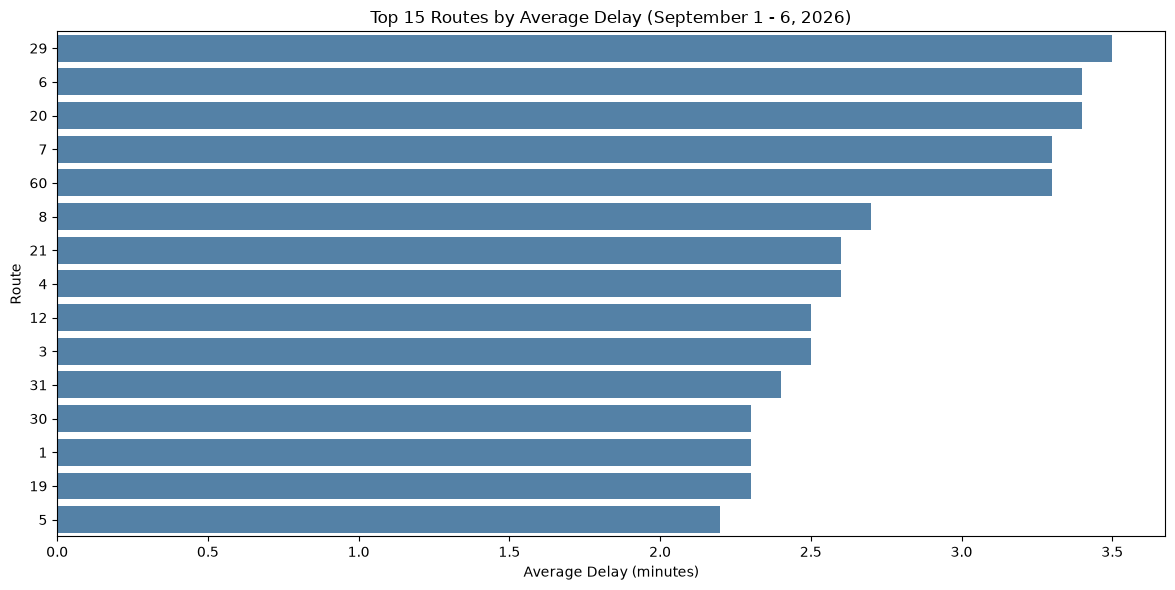

In [7]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

df = route_delays.DataFrame()

assorted_df = df.sort_values('average_delay', ascending = False)
df_top_15 = assorted_df.head(15)

df_top_15['route_id'] = df_top_15['route_id'].astype(str)

df_top_15 = df_top_15.reset_index()

plt.figure(figsize = (12, 6))
plt.xlabel('Average Delay (minutes)')
plt.ylabel('Route')
plt.title('Top 15 Routes by Average Delay (September 1 - 6, 2026)')
plt.tight_layout()

sns.barplot(
    data = df_top_15,
    y = 'route_id',
    x = 'average_delay',
    order = df_top_15['route_id'],
    color = 'steelblue'
)

plt.show()


## Chart 2: Maximum Delay by Route

Same 15 routes, ranked by their single worst delay instead. This spreads out a lot more from 11 minutes up to 
almost 64. Route 6 is the standout: only middling on average delay (3.4 min), but by far the worst on max 
delay, more than double the next route. That gap points to a one-off incident rather than a consistently 
bad schedule.

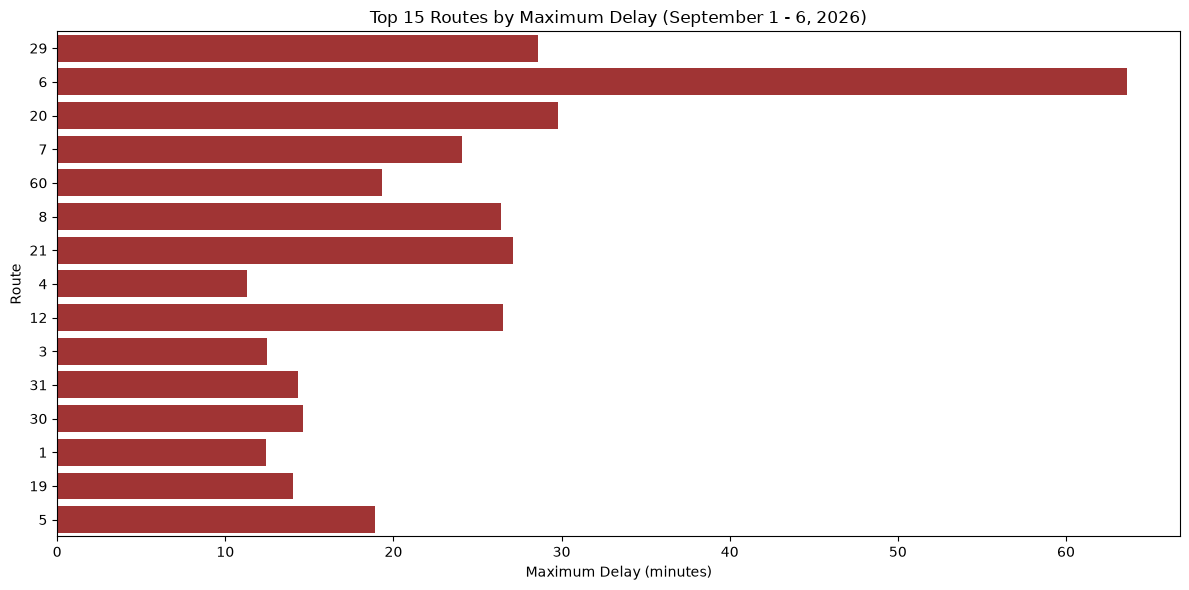

In [8]:
plt.figure(figsize = (12, 6))
plt.xlabel('Maximum Delay (minutes)')
plt.ylabel('Route')
plt.title('Top 15 Routes by Maximum Delay (September 1 - 6, 2026)')

sns.barplot(
    data = df_top_15,
    y = 'route_id',
    x = 'max_delay',
    order = df_top_15['route_id'],
    color = 'firebrick'
)

plt.tight_layout()
plt.show()

## Chart 3: Average vs. Maximum Delay

To see if the Route 6 pattern shows up network-wide, I checked the correlation between average and max 
delay across all routes: **r = 0.47** which is positive and moderate, so routes with worse averages do tend to have worse maxes.

Dropping Route 6 brings it down to **r = 0.38**, so part of that correlation is being driven by this one 
route, not a consistent trend.

Takeaway: average delay isn't a strong predictor of worst-case delay. A route can look fine on average and 
still be behind the network's single worst disruption, which is why both metrics matter, not just the average.

In [9]:
correlation = df['average_delay'].corr(df['max_delay'])

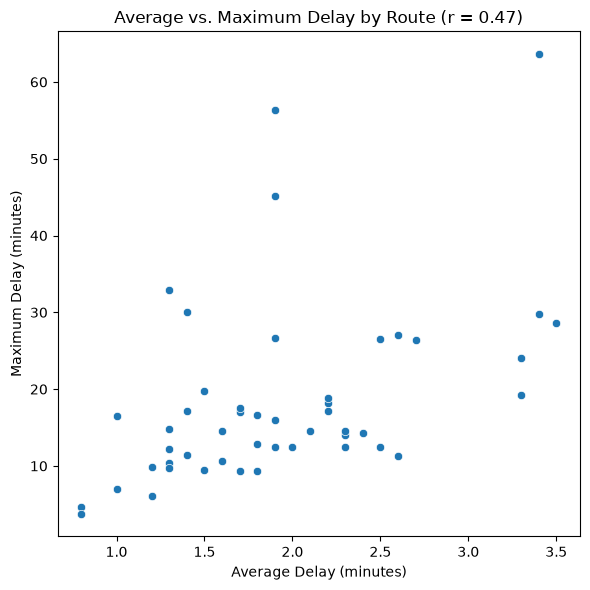

In [10]:
plt.figure(figsize = (6, 6))

sns.scatterplot(
    data = df,
    x = 'average_delay',
    y = 'max_delay')

plt.xlabel('Average Delay (minutes)')
plt.ylabel('Maximum Delay (minutes)')
plt.title(f'Average vs. Maximum Delay by Route (r = {correlation:.2f})')

plt.tight_layout()
plt.show()

## Summary

Most routes run close to schedule on average, typically within a few minutes. But average delay doesn't 
tell the whole story: it's only moderately correlated with a route's worst-case delay (r = 0.47, or 0.38 
without Route 6), meaning a route can look fine on average and still have a severe outlier.

Route 6 is the clearest case of this,  an unremarkable average delay, but the single worst delay in the 
network. It's the strongest candidate for further investigation if GRT wanted to dig into what caused it.

## Question 2: Coming Soon...